<a href="https://colab.research.google.com/github/antonellagambarte/vision-por-computadoras-II/blob/main/entrega%20final/prueba_modelos_con__img_color.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación de Modelos para Clasificación de Enfermedades en Plantas: MobileNetV2 vs MobileNetV3

En este notebook, se realiza una prueba en modo test de los modelos base con las imagenes a color del dataset


In [ ]:
test_execution = True

## Imports

In [ ]:
import gdown
import zipfile
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset
from torch.ao.quantization import get_default_qconfig_mapping, get_default_qat_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx, prepare_qat_fx, convert_fx

import warnings


# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Para asegurar reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

Usando dispositivo: cuda


## Carga del dataset


In [ ]:
url = "https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri"
output = "archivo.zip"
destino = "datos_zip"

def zip_is_valid(path):
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return False
    try:
        with zipfile.ZipFile(path, 'r') as z:
            return z.testzip() is None
    except Exception as e:
        print("Error:", e)
        return False

# descargar sólo si no existe o si el zip es inválido
if not zip_is_valid(output):
    print("Descargando...")
    gdown.download(url, output, quiet=False, fuzzy=True)
else:
    print(f"'{output}' ya existe.")

os.makedirs(destino, exist_ok=True)
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

print("Archivo extraído correctamente en :", destino)

'archivo.zip' ya existe.
Archivo extraído correctamente en : datos_zip


## Data transform

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Configuración para pruebas con dataset acotado (test_execution = True) o train con el dataset completo (test_execution = False)

In [ ]:
def stratified_split_indices(indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=None):
    if rng is None:
        rng = np.random.RandomState(0)
    train_idxs, val_idxs, test_idxs = [], [], []

    # agrupar por clase y partir cada grupo según fracciones
    class_to_idxs = {}
    for i in indices:
        class_to_idxs.setdefault(labels[i], []).append(i)

    for cls, idxs in class_to_idxs.items():
        idxs = list(idxs)
        rng.shuffle(idxs)
        n = len(idxs)

        # asumiendo suficientes muestras: calcular por fracción y asignar el resto a test
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        n_test = n - n_train - n_val

        train_idxs.extend(idxs[:n_train])
        val_idxs.extend(idxs[n_train:n_train + n_val])
        test_idxs.extend(idxs[n_train + n_val:n_train + n_val + n_test])

    return train_idxs, val_idxs, test_idxs

In [ ]:
data_dir = "datos_zip/plantvillage dataset/color"

full_dataset = datasets.ImageFolder(root=data_dir)
labels = [label for _, label in full_dataset.samples]

rng = np.random.RandomState(42)

if test_execution:
  # ------------ Crear subset reducido estratificado -----------------
  subset_indices = []
  reduction_factor = 0.1

  for class_idx in range(len(full_dataset.classes)):
      class_indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label == class_idx]
      n_samples = max(1, int(len(class_indices) * reduction_factor))
      chosen = rng.choice(class_indices, n_samples, replace=False).tolist()
      subset_indices.extend(chosen)

  # mezclar índices
  rng.shuffle(subset_indices)

  # ------------ Partición train / val / test (80% / 10% / 10%) -----------------
  train_indices, val_indices, test_indices = stratified_split_indices(
      subset_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
  )

  # Crear datasets con transform aplicado
  train_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=train_transform), train_indices)
  val_dataset   = Subset(datasets.ImageFolder(root=data_dir, transform=val_transform), val_indices)
  test_dataset  = Subset(datasets.ImageFolder(root=data_dir, transform=test_transform), test_indices)
else:
  # Segmentación de datos en 3 particiones: 80% train, 10% val, 10% test
  # estratificado sobre todo el dataset
  all_indices = list(range(len(full_dataset)))
  train_indices, val_indices, test_indices = stratified_split_indices(
      all_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
  )

  train_dataset = Subset(full_dataset, train_indices)
  val_dataset   = Subset(full_dataset, val_indices)
  test_dataset  = Subset(full_dataset, test_indices)

  train_dataset.dataset.transform = train_transform
  val_dataset.dataset.transform = val_transform
  test_dataset.dataset.transform = test_transform

## Configuración de DataLoaders

In [ ]:
batch_size = 64
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, prefetch_factor=2),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, prefetch_factor=2),
    'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, prefetch_factor=2)
}
num_classes = len(full_dataset.classes)
print(f"Clases: {num_classes}")
print(f"Datos de entrenamiento: {len(train_dataset)}")
print(f"Datos de validación: {len(val_dataset)}")

Clases: 38
Datos de entrenamiento: 4322
Datos de validación: 524


## Funciones de train y eval

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=5, patience=3):
    since = time.time()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc_pr': [], 'val_auc_pr': []
    }

    model.to(device)
    best_metric = -np.inf
    counter = 0   # ← Early stopping counter

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:

            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            all_labels = []
            all_preds = []
            all_probs = []  # lista de arrays por batch (cada batch: [batch_size, num_classes])

            for inputs, labels in dataloaders[phase]:

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)

                    # Probabilidades para TODAS las clases (multiclase)
                    probs = torch.softmax(outputs, dim=1)

                    # Predicción = argmax
                    _, preds = torch.max(outputs, 1)

                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # --- Acumulación ---
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

                all_labels.extend(labels.cuda().numpy())
                all_preds.extend(preds.cuda().numpy())
                all_probs.append(probs.detach().cuda().numpy())  # cada batch mantiene su shape

            # --- Probabilidades unificadas ---
            all_probs = np.vstack(all_probs)

            # --- Métricas ---
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

            # AUC-PR MACRO multiclase
            auc_pr = average_precision_score(
                all_labels,
                all_probs,
                average='macro'
            )

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f} AUC-PR: {auc_pr:.4f}')

            # --- Guardado para una época ---
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                history['train_recall'].append(epoch_recall)
                history['train_f1'].append(epoch_f1)
                history['train_auc_pr'].append(auc_pr)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                history['val_recall'].append(epoch_recall)
                history['val_f1'].append(epoch_f1)
                history['val_auc_pr'].append(auc_pr)

        # --- Early stopping (usa mejor AUC-PR) ---
        epoch_metric = history['val_auc_pr'][-1]

        if epoch_metric > best_metric:
            best_metric = epoch_metric
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping en epoch {epoch+1}")
                break

    time_elapsed = time.time() - since
    print(f'\nEntrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

    return model, history, time_elapsed



In [ ]:
def evaluate_model(model, dataloader, device_name='cuda'):
    """Evalúa precisión, recall macro, f1 score y tiempo de inferencia"""
    model.to(device_name)
    model.eval()

    correct = 0
    total = 0
    start_time = time.time()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device_name)
            labels = labels.to(device_name)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, predicted = torch.max(outputs.data, 1)

            # Accuracy
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Recall macro
            all_preds.extend(predicted.cuda().numpy())
            all_labels.extend(labels.cuda().numpy())
            all_probs.extend(probs.cuda().numpy())

    end_time = time.time()
    inference_time = end_time - start_time

    accuracy = correct / total
    recall_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc_pr = average_precision_score(all_labels, all_probs, average='macro')

    return accuracy, recall_macro, f1_macro, auc_pr, inference_time

In [ ]:
def get_model_size(model, model_name="model"):
    """Guarda el modelo temporalmente para medir su tamaño en disco"""
    torch.save(model.state_dict(), f"{model_name}.pth")
    size_mb = os.path.getsize(f"{model_name}.pth") / 1e6
    os.remove(f"{model_name}.pth")
    return size_mb

In [ ]:
def plot_compare_train_val(train_stats, val_stats, ylabel, title=""):
    plt.figure(figsize=(8,5))
    plt.plot(train_stats, label=f"Train {ylabel}")
    plt.plot(val_stats, label=f"Val {ylabel}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    if title != "":
        plt.title(title)
    else:
        plt.title(f"Training vs Validation {ylabel}")
    plt.legend()
    plt.show()

In [ ]:
# ---------------------------------------------------------------------
# --- 1. Obtener labels y scores (probabilidades) de un modelo --------
# ---------------------------------------------------------------------

def get_predictions(model, dataloader, device='cuda'):
    model.to(device)
    model.eval()

    all_labels = []
    all_scores = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            scores = torch.nn.functional.softmax(outputs, dim=1)

            all_labels.extend(labels.cuda().numpy())
            all_scores.extend(scores.cuda().numpy())

    return np.array(all_labels), np.array(all_scores)


# ---------------------------------------------------------------------
# --- 2. Calcular ROC macro-average -----------------------------------
# ---------------------------------------------------------------------

def compute_macro_roc(y_onehot, y_scores):
    n_classes = y_onehot.shape[1]

    fpr = {}
    tpr = {}
    roc_auc = {}

    # ROC por clase
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_onehot[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average: interpolar y promediar
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, macro_auc


# ---------------------------------------------------------------------
# --- 3. Función completa de comparación ------------------------------
# ---------------------------------------------------------------------

def compare_models_macro(models, model_names, dataloader, device='cuda'):
    """
    models: lista de modelos PyTorch
    model_names: lista de strings (nombres)
    dataloader: dataloader de test
    """

    assert len(models) == len(model_names), "La cantidad de modelos y nombres debe coincidir"

    # Obtener predicciones del primer modelo para binarizar labels
    y_true, _ = get_predictions(models[0], dataloader, device)
    lb = LabelBinarizer().fit(y_true)
    y_onehot = lb.transform(y_true)

    roc_results = []
    pr_results = []

    # --------------------------------------------------------------
    # Procesar cada modelo
    # --------------------------------------------------------------
    for model, name in zip(models, model_names):
        print(f"Procesando modelo: {name}")

        y_true_i, y_scores_i = get_predictions(model, dataloader, device)

        # ROC macro
        fpr_macro, tpr_macro, auc_macro = compute_macro_roc(y_onehot, y_scores_i)
        roc_results.append((name, fpr_macro, tpr_macro, auc_macro))

        # PR macro (Scikit-Learn ya lo permite directo)
        ap_macro = average_precision_score(y_onehot, y_scores_i, average='macro')
        pr_results.append((name, ap_macro, y_scores_i))

    # --------------------------------------------------------------
    # Graficar ROC Macro
    # --------------------------------------------------------------
    plt.figure(figsize=(10, 8))
    for (name, fpr, tpr, auc_macro) in roc_results:
        plt.plot(fpr, tpr, label=f"{name} (AUC Macro = {auc_macro:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC Macro-Average - Comparación de Modelos')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------------
    # Graficar PR Macro
    # --------------------------------------------------------------
    plt.figure(figsize=(10, 8))

    for (name, ap_macro, y_scores) in pr_results:
        # Curvas PR por clase -> promediadas
        n_classes = y_onehot.shape[1]
        precisions = []
        recalls = []

        for c in range(n_classes):
            p, r, _ = precision_recall_curve(y_onehot[:, c], y_scores[:, c])
            # Interpolación
            p_interp = np.interp(np.linspace(0, 1, 500), r[::-1], p[::-1])
            precisions.append(p_interp)

        macro_precision_curve = np.mean(precisions, axis=0)
        macro_recall_curve = np.linspace(0, 1, 500)

        plt.plot(macro_recall_curve, macro_precision_curve,
                 label=f"{name} (AP Macro = {ap_macro:.3f})")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Macro-Average - Comparación de Modelos')
    plt.legend()
    plt.grid(True)
    plt.show()


## Entrenamientos

In [ ]:
num_epochs = 50

--- Entrenando Modelo 1: MobileNetV2 (Baseline) ---
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 218MB/s]

Epoch 1/50
----------


train Loss: 2.7497 Acc: 0.3401 Recall: 0.1428 F1: 0.1356 AUC-PR: 0.2513
val Loss: 2.1633 Acc: 0.5382 Recall: 0.2979 F1: 0.2894 AUC-PR: 0.5768
Epoch 2/50
----------
train Loss: 1.9128 Acc: 0.6124 Recall: 0.3840 F1: 0.3775 AUC-PR: 0.6182
val Loss: 1.6075 Acc: 0.6966 Recall: 0.4647 F1: 0.4588 AUC-PR: 0.7575
Epoch 3/50
----------
train Loss: 1.4850 Acc: 0.7388 Recall: 0.5193 F1: 0.5131 AUC-PR: 0.7557
val Loss: 1.2973 Acc: 0.7500 Recall: 0.5305 F1: 0.5298 AUC-PR: 0.8273
Epoch 4/50
----------
train Loss: 1.2149 Acc: 0.7982 Recall: 0.5941 F1: 0.5885 AUC-PR: 0.8209
val Loss: 1.0888 Acc: 0.8092 Recall: 0.6336 F1: 0.6543 AUC-PR: 0.8702
Epoch 5/50
----------
train Loss: 1.0342 Acc: 0.8318 Recall: 0.6494 F1: 0.6492 AUC-PR: 0.8579
val Loss: 0.9493 Acc: 0.8435 Recall: 0.6986 F1: 0.7072 AUC-PR: 0.8852
Epoch 6/50
----------
train Loss: 0.9013 Acc: 0.8528 Recall: 0.6878 F1: 0.6922 AUC-PR: 0.8838
val Loss: 0.8407 Acc: 0.8550 Recall: 0.7229 F1: 0.7311 AUC-PR: 0.8968
Epoch 7/50
----------
train Loss: 0.80

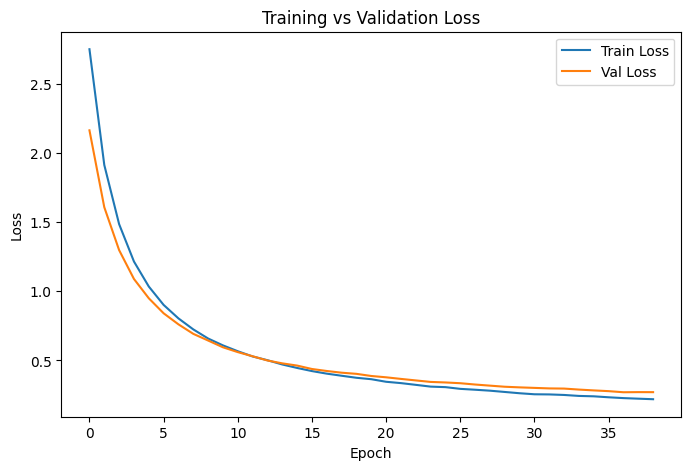

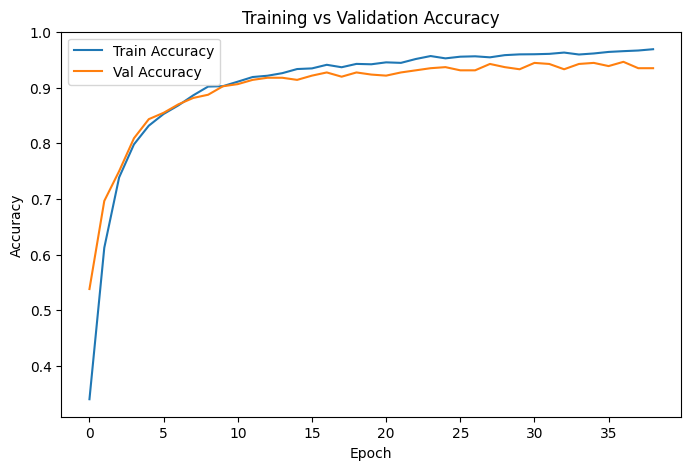

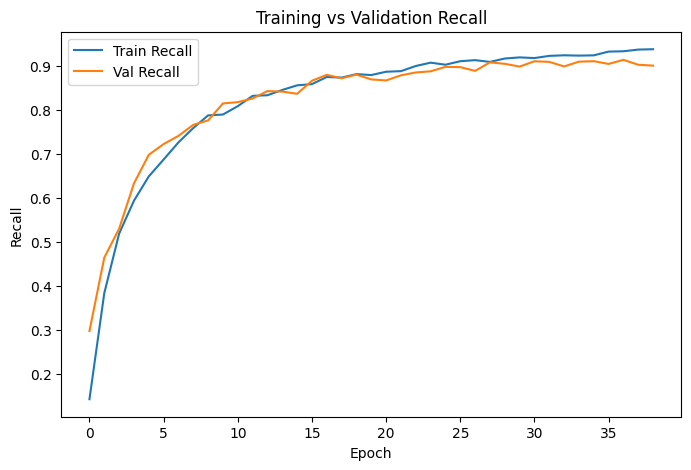

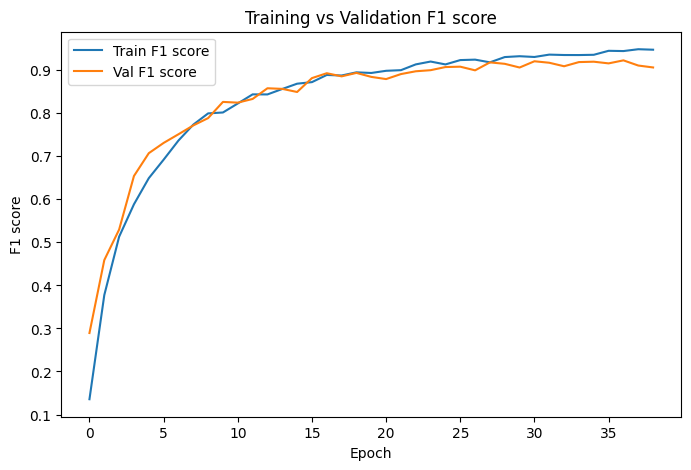

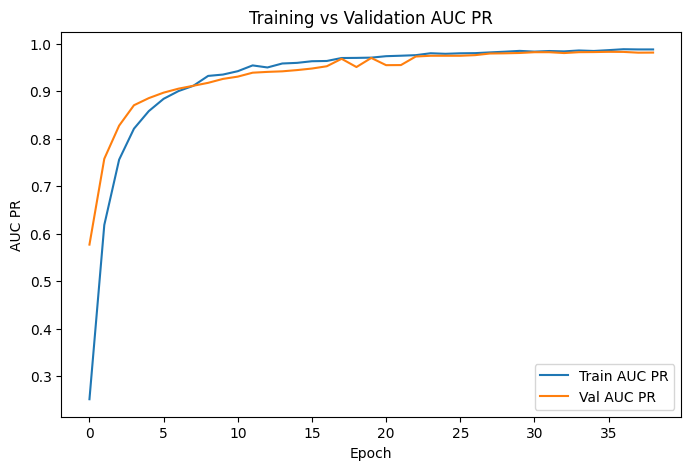

In [ ]:
print("--- Entrenando Modelo 1: MobileNetV2 (Baseline) ---")

# Cargar modelo preentrenado
model_v2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Congelar capas
for param in model_v2.features.parameters():
    param.requires_grad = False

# Modificación del clasificador
in_features = model_v2.classifier[1].in_features
model_v2.classifier = nn.Sequential(
    nn.Linear(in_features, num_classes)
)

# Definir criterio y optimizador
criterion = nn.CrossEntropyLoss()
optimizer_v2 = optim.SGD(model_v2.classifier.parameters(), lr=0.01)

# Entrenamiento
model_v2, hist_v2, time_v2 = train_model(model_v2, criterion, optimizer_v2, num_epochs=num_epochs)

plot_compare_train_val(train_stats=hist_v2['train_loss'], val_stats=hist_v2['val_loss'], ylabel='Loss')
plot_compare_train_val(train_stats=hist_v2['train_acc'], val_stats=hist_v2['val_acc'], ylabel='Accuracy')
plot_compare_train_val(train_stats=hist_v2['train_recall'], val_stats=hist_v2['val_recall'], ylabel='Recall')
plot_compare_train_val(train_stats=hist_v2['train_f1'], val_stats=hist_v2['val_f1'], ylabel='F1 score')
plot_compare_train_val(train_stats=hist_v2['train_auc_pr'], val_stats=hist_v2['val_auc_pr'], ylabel='AUC PR')

In [ ]:
plot_compare_train_val(train_stats=hist_v2['train_auc_pr'], val_stats=hist_v2['val_auc_pr'], ylabel='AUC PR')


--- Entrenando Modelo 2: MobileNetV3 Small ---
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 171MB/s]


Epoch 1/50
----------
train Loss: 3.0697 Acc: 0.3232 Recall: 0.1688 F1: 0.1598 AUC-PR: 0.1714
val Loss: 2.5462 Acc: 0.4198 Recall: 0.2009 F1: 0.1932 AUC-PR: 0.3655
Epoch 2/50
----------
train Loss: 2.2590 Acc: 0.5400 Recall: 0.3269 F1: 0.3189 AUC-PR: 0.4505
val Loss: 1.9576 Acc: 0.5592 Recall: 0.3443 F1: 0.3294 AUC-PR: 0.5886
Epoch 3/50
----------
train Loss: 1.8150 Acc: 0.6247 Recall: 0.4073 F1: 0.3993 AUC-PR: 0.6005
val Loss: 1.5733 Acc: 0.6546 Recall: 0.4305 F1: 0.4182 AUC-PR: 0.7068
Epoch 4/50
----------
train Loss: 1.4943 Acc: 0.6964 Recall: 0.4811 F1: 0.4739 AUC-PR: 0.7021
val Loss: 1.3165 Acc: 0.7290 Recall: 0.5180 F1: 0.5160 AUC-PR: 0.7603
Epoch 5/50
----------
train Loss: 1.2772 Acc: 0.7476 Recall: 0.5417 F1: 0.5368 AUC-PR: 0.7520
val Loss: 1.1366 Acc: 0.7691 Recall: 0.5635 F1: 0.5587 AUC-PR: 0.7955
Epoch 6/50
----------
train Loss: 1.0977 Acc: 0.7830 Recall: 0.5877 F1: 0.5868 AUC-PR: 0.7961
val Loss: 0.9984 Acc: 0.7996 Recall: 0.6068 F1: 0.6036 AUC-PR: 0.8203
Epoch 7/50
-----

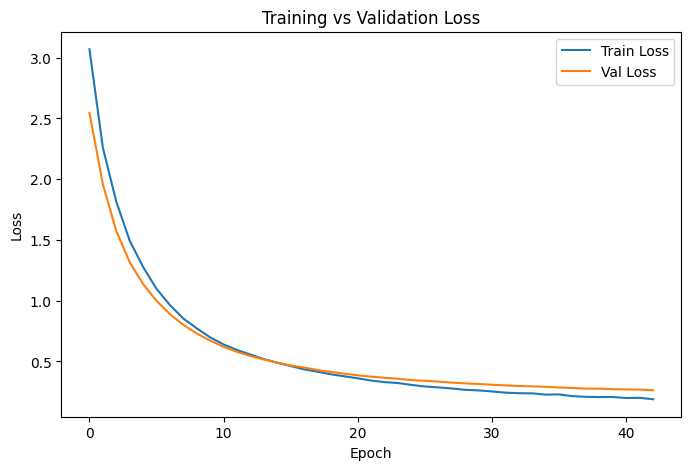

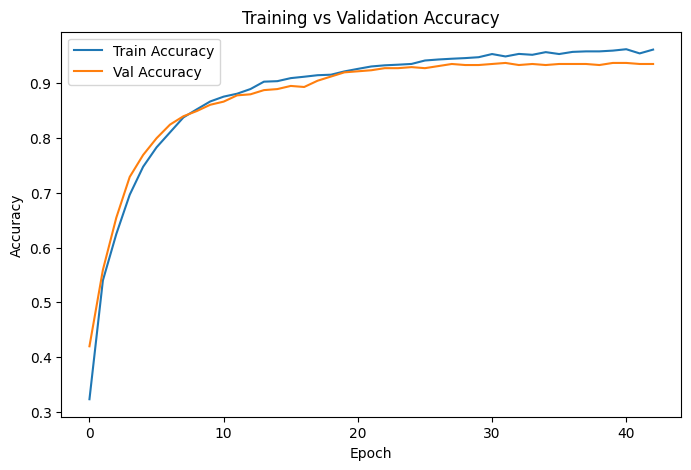

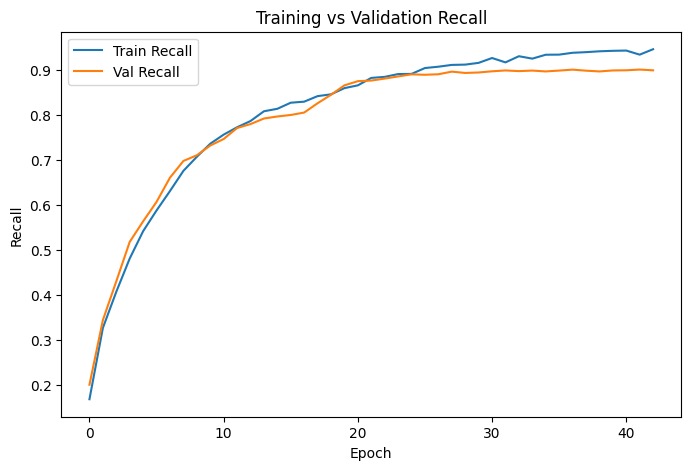

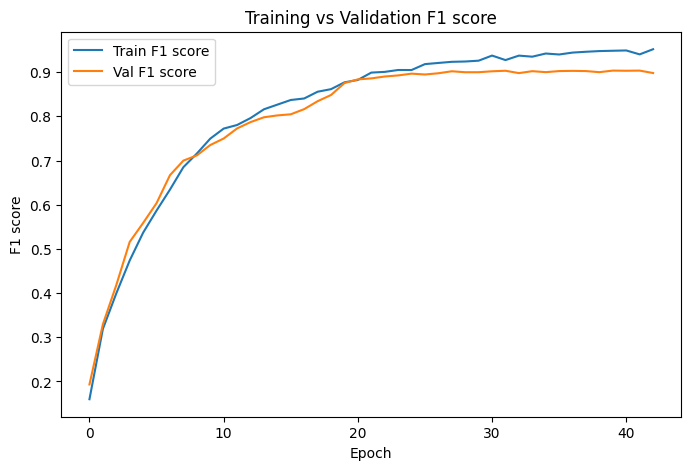

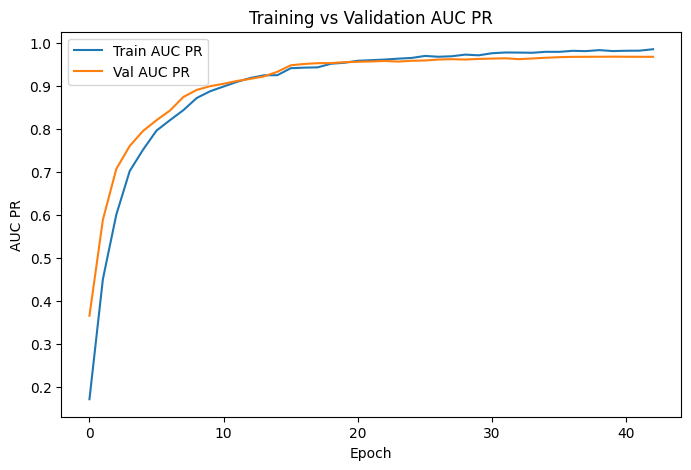

In [ ]:
print("\n--- Entrenando Modelo 2: MobileNetV3 Small ---")

# Cargar modelo preentrenado "Small"
model_v3 = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Congelar capas
for param in model_v3.features.parameters():
    param.requires_grad = False

# Modificación del clasificador
# Vamos a reemplazar la última capa lineal (índice 3)
in_features_v3 = model_v3.classifier[3].in_features
model_v3.classifier[3] = nn.Linear(in_features_v3, num_classes)

# Definir criterio y optimizador
criterion = nn.CrossEntropyLoss()
optimizer_v3 = optim.SGD(model_v3.classifier.parameters(), lr=0.01)

# Entrenamiento
model_v3, hist_v3, time_v3 = train_model(model_v3, criterion, optimizer_v3, num_epochs=num_epochs)

# Graficar preformance
plot_compare_train_val(train_stats=hist_v3['train_loss'], val_stats=hist_v3['val_loss'], ylabel='Loss')
plot_compare_train_val(train_stats=hist_v3['train_acc'], val_stats=hist_v3['val_acc'], ylabel='Accuracy')
plot_compare_train_val(train_stats=hist_v3['train_recall'], val_stats=hist_v3['val_recall'], ylabel='Recall')
plot_compare_train_val(train_stats=hist_v3['train_f1'], val_stats=hist_v3['val_f1'], ylabel='F1 score')
plot_compare_train_val(train_stats=hist_v3['train_auc_pr'], val_stats=hist_v3['val_auc_pr'], ylabel='AUC PR')